INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarke

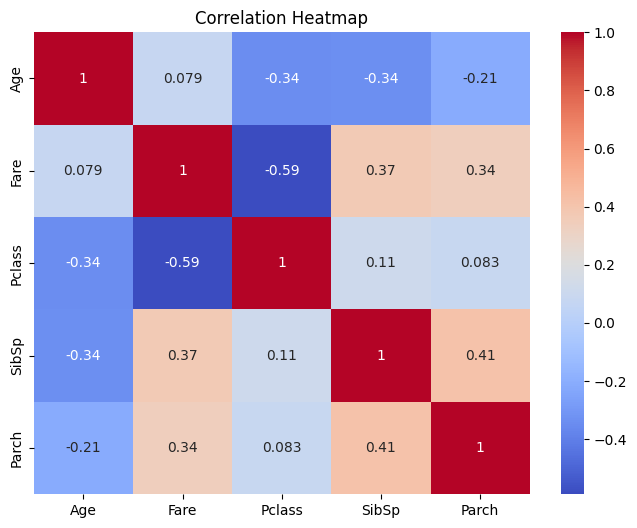


PCA Result:
         PC1        PC2
0 -12.623969  -1.756334
1 -10.274271   1.574270
2  34.309661 -10.181624
3  -6.210873   9.599696
4  -8.171573   4.661549


In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("/kaggle/input/datasets/ghadeeralmudhi/titanic-dataset/Titanic-Dataset.csv")
print("INFO:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe())

df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns=['Cabin'], inplace=True)

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Fare'] >= lower_bound) & (df['Fare'] <= upper_bound)]

num_cols = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']

minmax = MinMaxScaler()
df_minmax = pd.DataFrame(minmax.fit_transform(df[num_cols]), columns=num_cols)
zscore = StandardScaler()
df_zscore = pd.DataFrame(zscore.fit_transform(df[num_cols]), columns=num_cols)

print("\nMin-Max Scaled Data:")
print(df_minmax.head())

print("\nZ-score Standardized Data:")
print(df_zscore.head())

plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df[num_cols])
df_pca = pd.DataFrame(df_pca, columns=['PC1', 'PC2'])

print("\nPCA Result:")
print(df_pca.head())